# IMPORT NECESSARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

# WEB SCRAPING DATA USING BEAUTIFUL SOUP

In [3]:
#DEFINE URL + REQUEST

url = "https://www.gutenberg.org/ebooks/search/?sort_order=downloads"
response = requests.get(url)
print(response.status_code)

200


In [6]:
#PARSING HTML (BEAUTIFUL SOUP)

soup=BeautifulSoup(response.text,"html.parser") # converts raw HTML-> structured format

In [7]:
#FIND BOOK CONTAINERS

books = soup.find_all("li", class_="booklink")

print(len(books))

25


In [8]:
#INSPECT ONE BOOK
book = books[0]
print(book)

<li class="booklink">
<a accesskey="1" class="link" href="/ebooks/84">
<span class="cell leftcell with-cover">
<img alt="" class="cover-thumb" src="/cache/epub/84/pg84.cover.small.jpg"/>
</span>
<span class="cell content">
<span class="title">Frankenstein; or, the modern prometheus</span>
<span class="subtitle">Mary Wollstonecraft Shelley</span>
<span class="extra">138892 downloads</span>
</span>
<span class="hstrut"></span>
</a>
</li>


In [9]:
#EXTRACT SINGLE BOOK DATA

book = books[0]

# Title
title = book.find("span", class_="title").text

# Author
author = book.find("span", class_="subtitle").text

# Downloads
downloads = book.find("span", class_="extra").text

# Link
link = book.find("a")["href"]
full_link = "https://www.gutenberg.org" + link

print(title)
print(author)
print(downloads)
print(full_link)

Frankenstein; or, the modern prometheus
Mary Wollstonecraft Shelley
138892 downloads
https://www.gutenberg.org/ebooks/84


In [10]:
downloads = book.find("span", class_="extra").text

# Clean it
downloads_clean = downloads.replace(" downloads", "")
downloads_clean = int(downloads_clean)

print(downloads_clean)

138892


In [11]:
titles = []
authors = []
downloads_list = []
links = []

for book in books:
    
    # Title
    title = book.find("span", class_="title").text
    
    # Author
    author = book.find("span", class_="subtitle").text
    
    # Downloads (clean)
    downloads = book.find("span", class_="extra").text
    downloads = downloads.replace(" downloads", "")
    downloads = int(downloads)
    
    # Link
    link = book.find("a")["href"]
    full_link = "https://www.gutenberg.org" + link
    
    # Append
    titles.append(title)
    authors.append(author)
    downloads_list.append(downloads)
    links.append(full_link)

print(len(titles))

25


In [12]:
import pandas as pd

df = pd.DataFrame({
    "Title": titles,
    "Author": authors,
    "Downloads": downloads_list,
    "Link": links
})

df.head()

,Title,Author,Downloads,Link
0,"Frankenstein; or, the modern prometheus",Mary Wollstonecraft Shelley,138892,https://www.gutenberg.org/ebooks/84
1,"The City of God, Volume I",Saint of Hippo Augustine,137767,https://www.gutenberg.org/ebooks/45304
2,"Moby Dick; Or, The Whale",Herman Melville,118803,https://www.gutenberg.org/ebooks/2701
3,Pride and Prejudice,Jane Austen,101946,https://www.gutenberg.org/ebooks/1342
4,Romeo and Juliet,William Shakespeare,76795,https://www.gutenberg.org/ebooks/1513


In [13]:
# Title Length
df["Title_Length"] = df["Title"].apply(len)

# Category based on title length
df["Category"] = df["Title_Length"].apply(lambda x: "Short" if x < 20 else "Long")

# Book ID from link
df["Book_ID"] = df["Link"].apply(lambda x: x.split("/")[-1])

# Page number (current page = 1)
df["Page"] = 1

df.head()

,Title,Author,Downloads,Link,Title_Length,Category,Book_ID,Page
0,"Frankenstein; or, the modern prometheus",Mary Wollstonecraft Shelley,138892,https://www.gutenberg.org/ebooks/84,39,Long,84,1
1,"The City of God, Volume I",Saint of Hippo Augustine,137767,https://www.gutenberg.org/ebooks/45304,25,Long,45304,1
2,"Moby Dick; Or, The Whale",Herman Melville,118803,https://www.gutenberg.org/ebooks/2701,24,Long,2701,1
3,Pride and Prejudice,Jane Austen,101946,https://www.gutenberg.org/ebooks/1342,19,Short,1342,1
4,Romeo and Juliet,William Shakespeare,76795,https://www.gutenberg.org/ebooks/1513,16,Short,1513,1


In [15]:
all_data = []

for page in range(0, 20):   # 20 pages → ~500 rows
    
    url = f"https://www.gutenberg.org/ebooks/search/?sort_order=downloads&start_index={page*25}"
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("li", class_="booklink")
    
    for book in books:
        
        title = book.find("span", class_="title").text
        
        author_tag = book.find("span", class_="subtitle")
        author = author_tag.text if author_tag else "Unknown"
        
        downloads = book.find("span", class_="extra").text
        downloads = int(downloads.replace(" downloads", ""))
        
        link = book.find("a")["href"]
        full_link = "https://www.gutenberg.org" + link
        
        # Derived features
        title_length = len(title)
        category = "Short" if title_length < 20 else "Long"
        book_id = full_link.split("/")[-1]
        
        all_data.append({
            "Title": title,
            "Author": author,
            "Downloads": downloads,
            "Link": full_link,
            "Title_Length": title_length,
            "Category": category,
            "Book_ID": book_id,
            "Page": page + 1
        })

df = pd.DataFrame(all_data)

print(len(df))
df.head()

500


,Title,Author,Downloads,Link,Title_Length,Category,Book_ID,Page
0,"Frankenstein; or, the modern prometheus",Mary Wollstonecraft Shelley,138892,https://www.gutenberg.org/ebooks/84,39,Long,84,1
1,"The City of God, Volume I",Saint of Hippo Augustine,137767,https://www.gutenberg.org/ebooks/45304,25,Long,45304,1
2,"Moby Dick; Or, The Whale",Herman Melville,118803,https://www.gutenberg.org/ebooks/2701,24,Long,2701,1
3,Pride and Prejudice,Jane Austen,101946,https://www.gutenberg.org/ebooks/1342,19,Short,1342,1
4,Romeo and Juliet,William Shakespeare,76795,https://www.gutenberg.org/ebooks/1513,16,Short,1513,1


In [16]:
# Author Name Length
df["Author_Length"] = df["Author"].apply(len)

# Popularity Category based on Downloads
df["Popularity"] = df["Downloads"].apply(
    lambda x: "High" if x > 100000 else ("Medium" if x > 50000 else "Low")
)

# URL Length
df["Link_Length"] = df["Link"].apply(len)

# Downloads in Thousands (scaled feature)
df["Downloads_K"] = df["Downloads"] / 1000

df.head()

,Title,Author,Downloads,Link,Title_Length,Category,Book_ID,Page,Author_Length,Popularity,Link_Length,Downloads_K
0,"Frankenstein; or, the modern prometheus",Mary Wollstonecraft Shelley,138892,https://www.gutenberg.org/ebooks/84,39,Long,84,1,27,High,35,138.892
1,"The City of God, Volume I",Saint of Hippo Augustine,137767,https://www.gutenberg.org/ebooks/45304,25,Long,45304,1,24,High,38,137.767
2,"Moby Dick; Or, The Whale",Herman Melville,118803,https://www.gutenberg.org/ebooks/2701,24,Long,2701,1,15,High,37,118.803
3,Pride and Prejudice,Jane Austen,101946,https://www.gutenberg.org/ebooks/1342,19,Short,1342,1,11,High,37,101.946
4,Romeo and Juliet,William Shakespeare,76795,https://www.gutenberg.org/ebooks/1513,16,Short,1513,1,19,Medium,37,76.795


# EXPORT DATA TO CSV

In [17]:
#SAVE DATA
df.to_csv("gutenberg_books.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


# EXPLORATORY DATA ANALYSIS

In [22]:
#DATA UNDERSTANDING

df.shape

(500, 12)

# 🎤 Interpretation:
> No missing values found

> Dataset is clean and ready for analysis ✔

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          500 non-null    str    
 1   Author         500 non-null    str    
 2   Downloads      500 non-null    int64  
 3   Link           500 non-null    str    
 4   Title_Length   500 non-null    int64  
 5   Category       500 non-null    str    
 6   Book_ID        500 non-null    str    
 7   Page           500 non-null    int64  
 8   Author_Length  500 non-null    int64  
 9   Popularity     500 non-null    str    
 10  Link_Length    500 non-null    int64  
 11  Downloads_K    500 non-null    float64
dtypes: float64(1), int64(5), str(6)
memory usage: 47.0 KB


# We have:

**Numerical:** Downloads, Title_Length, Author_Length, Link_Length, Page, Downloads_K

**Categorical/Text:** Title, Author, Category, Popularity

# 🎤 Interpretation:

> The dataset contains both numerical and categorical variables

> Suitable for univariate, bivariate, and multivariate analysis

In [20]:
df.describe()

,Downloads,Title_Length,Page,Author_Length,Link_Length,Downloads_K
count,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,17934.20600,36.308000,10.500000,16.580000,37.42400,17.934206
std,14390.13505,23.870499,5.772056,7.518821,0.84951,14.390135
min,10142.00000,4.000000,1.000000,4.000000,35.00000,10.142000
25%,11339.00000,20.000000,5.750000,12.000000,37.00000,11.339000
50%,13269.00000,31.000000,10.500000,15.000000,38.00000,13.269000
75%,17588.75000,46.000000,15.250000,19.000000,38.00000,17.588750
max,138892.00000,182.000000,20.000000,52.000000,38.00000,138.892000


# KEY STATISTICS 

# 📊 Downloads

> Min: 10,142

> Max: 138,892

> Mean: ~17,934

# 🎤 Interpretation:
> Most books have moderate downloads (~10k–20k)

> Few books have very high downloads → outliers present

# 📊 Title Length
> Min: 4

> Max: 182

> Mean: ~36

# 🎤 Interpretation:
> Titles vary widely in length

> Majority are medium-sized titles

# 📊 Author Length

> Range: 4 → 52

# 👉 Indicates:

> simple vs complex author names

# MOST IMPORTANT INSIGHT

# 👉 Downloads have high variation (std = 14390)

# 🎤 Meaning:

> Book popularity is not uniform

> Some books are extremely popular

In [21]:
df.isnull().sum()

Title            0
Author           0
Downloads        0
Link             0
Title_Length     0
Category         0
Book_ID          0
Page             0
Author_Length    0
Popularity       0
Link_Length      0
Downloads_K      0
dtype: int64

> 👉 All values = 0

# 🎤 Interpretation:
> No missing values found

> Dataset is clean and ready for analysis ✔

# FINAL DATA UNDERSTANDING SUMMARY

> The dataset contains 500 records with 12 features.

> No missing values were found, indicating clean data.

> Download counts vary significantly, showing unequal popularity among books.

> Most books fall in a moderate download range, while a few have extremely high downloads.

> Feature engineering helped create meaningful variables like popularity and title length

# UNIVARIATE ANALYSIS

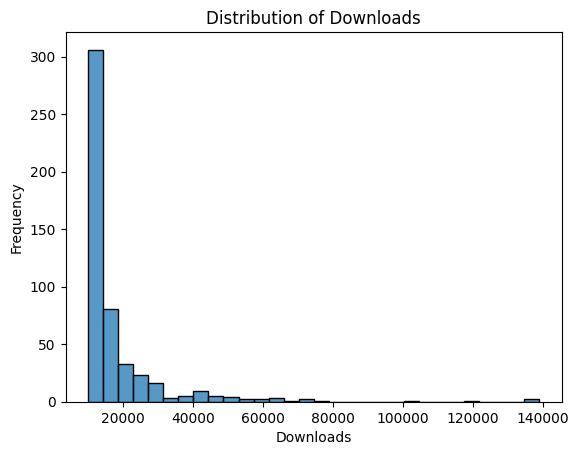

In [23]:
#Plot: Downloads Distribution

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df["Downloads"], bins=30)
plt.title("Distribution of Downloads")
plt.xlabel("Downloads")
plt.ylabel("Frequency")
plt.show()

# 📊 Observation 1:

> Most values are concentrated on the left side

# 📊 Observation 2:

> Few values extend far to the right side

# MEANING

> The dataset is right-skewed (positively skewed)

> Most books have low to medium downloads

> Very few books have very high downloads

# KEY INSIGHT:

> Book popularity is uneven

> Few books are extremely popular

> The majority have moderate popularity

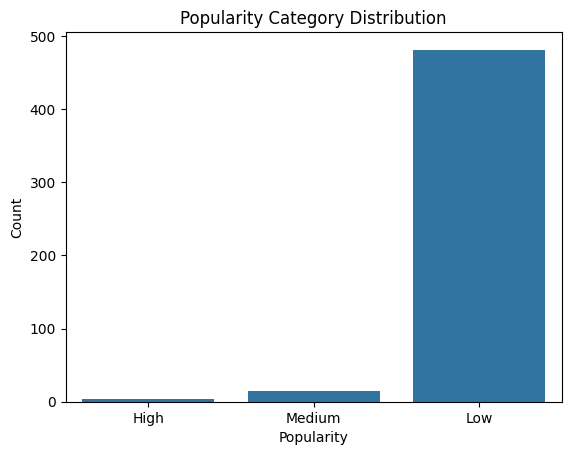

In [24]:
#Popularity Distribution

plt.figure()
sns.countplot(x="Popularity", data=df)
plt.title("Popularity Category Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

# 📊 Observation 1:

> Most books fall into the Low and Medium categories

# 📊 Observation 2:

> Very few books are in the High category

# MEANING

> High-popularity books are rare

> The majority of books have an average reach

 # KEY INSIGHT

> Popularity is not equally distributed

→ Only a small number of books dominate downloads

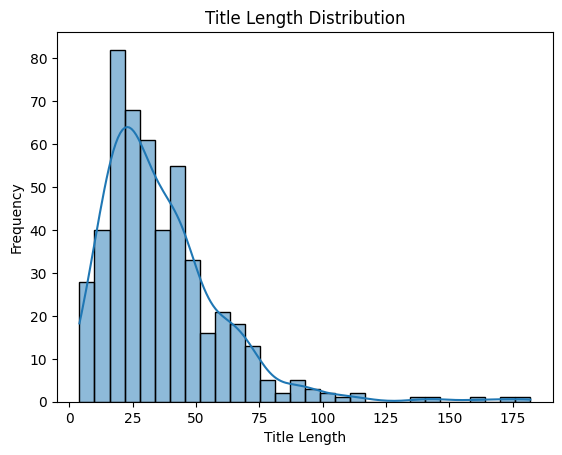

In [26]:
#Title Length Distribution

plt.figure()
sns.histplot(df["Title_Length"], bins=30,kde=True)
plt.title("Title Length Distribution")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

# BIVARIATE ANALYSIS

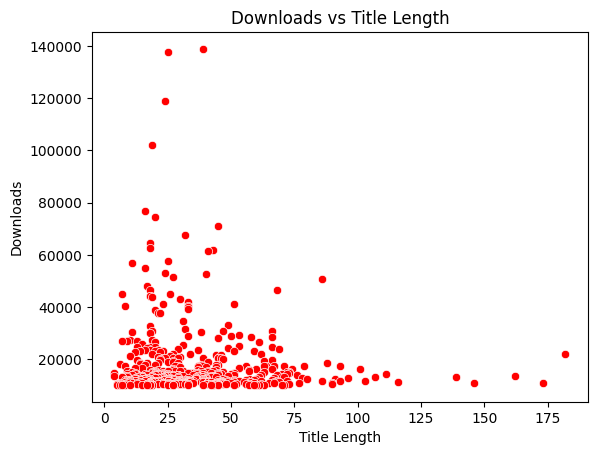

In [29]:
plt.figure()
sns.scatterplot(x="Title_Length", y="Downloads", data=df,color = "red")
plt.title("Downloads vs Title Length")
plt.xlabel("Title Length")
plt.ylabel("Downloads")
plt.show()

# 📊 Observation 1:

> Points are widely scattered across the graph

> No clear upward or downward pattern

# 📊 Observation 2:

> High download values appear at different title lengths

> Not concentrated in one specific range

# MEANING

> There is no strong relationship between title length and downloads

# KEY INSIGHT

> Title length does NOT significantly affect book popularity

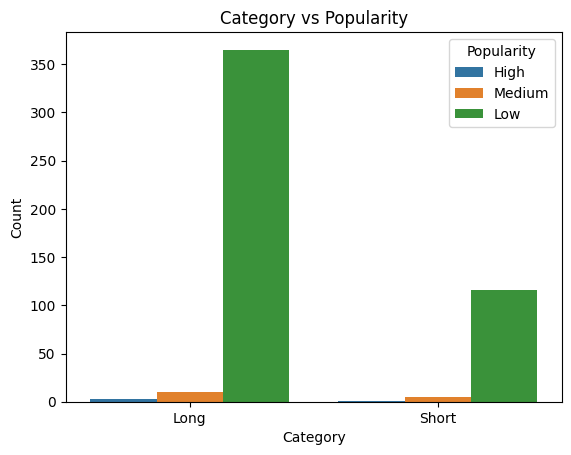

In [30]:
#Category vs Popularity

plt.figure()
sns.countplot(x="Category", hue="Popularity", data=df)
plt.title("Category vs Popularity")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# 📊 Observation 1:

> Both Short and Long categories contain all three popularity levels (Low, Medium, High)

# 📊 Observation 2:

> No single category (Short/Long) dominates in High popularity

# 📊 Observation 3:

> Distribution looks mixed across categories

# MEANING

> Title category (Short vs Long) does not strongly influence popularity

# KEY INSIGHT

> Both short and long titles can be popular or unpopular

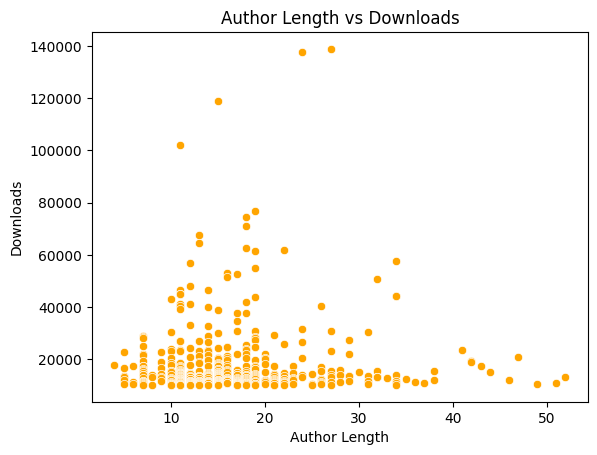

In [32]:
#Author Length vs Downloads

plt.figure()
sns.scatterplot(x="Author_Length", y="Downloads", data=df,color = "orange")
plt.title("Author Length vs Downloads")
plt.xlabel("Author Length")
plt.ylabel("Downloads")
plt.show()

# 📊 Observation 1:

> Data points are scattered randomly

# 📊 Observation 2:

> No clear upward or downward trend

# 📊 Observation 3:

> High downloads occur at different author name lengths

# MEANING

> There is no strong relationship between author name length and downloads

# KEY INSIGHT

> Author name length does NOT influence book popularity

# MULTIVARIATE ANALYSIS

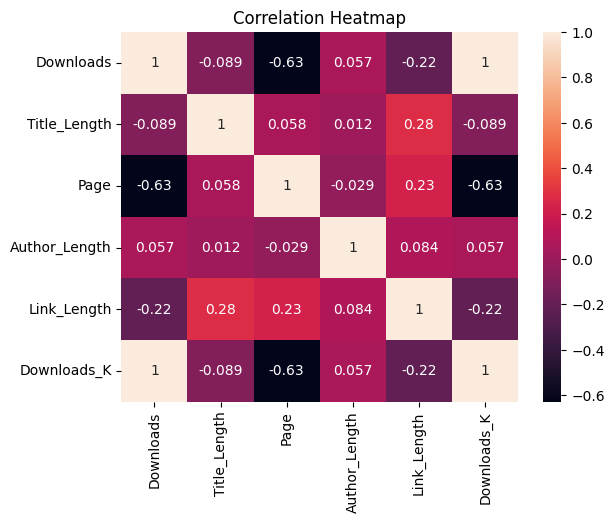

In [33]:
#Correlation Heatmap

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# 🎯 Interpretation:
> Most values are close to 0

> No strong positive or negative correlation

# 🧠 Meaning:

👉 Variables are mostly independent

👉 Downloads are not strongly related to title length, author length, etc.

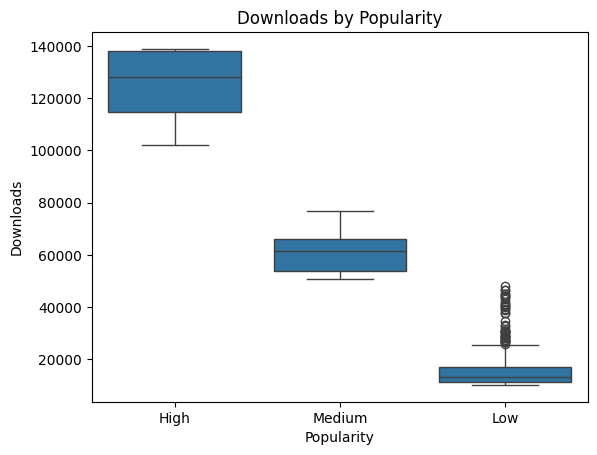

In [38]:
#Downloads vs Popularity (Boxplot)

plt.figure()
sns.boxplot(x="Popularity", y="Downloads", data=df)
plt.title("Downloads by Popularity")
plt.xlabel("Popularity")
plt.ylabel("Downloads")
plt.show()



# 🎯 Interpretation:

> Most values are close to 0

> No strong positive or negative correlation

# 🧠 Meaning:

👉 Variables are mostly independent

👉 Downloads are not strongly related to title length, author length, etc.

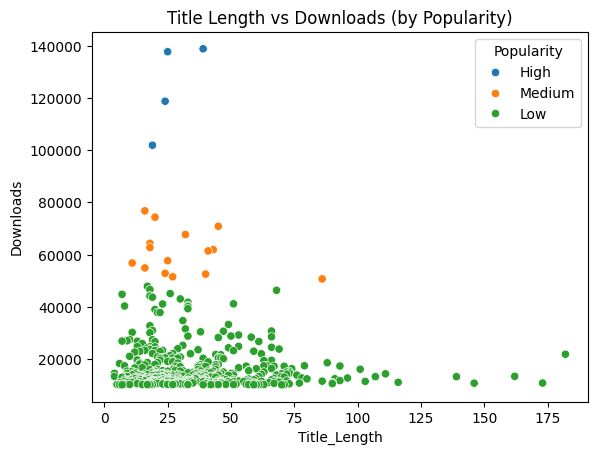

In [35]:
#Title Length vs Downloads (with Popularity Hue)

plt.figure()
sns.scatterplot(x="Title_Length", y="Downloads", hue="Popularity", data=df)
plt.title("Title Length vs Downloads (by Popularity)")
plt.show()

# 🎯 Interpretation:

> Points are scattered

> High/Low popularity appears across different title lengths

# 🧠 Meaning:

👉 Title length does not determine popularity

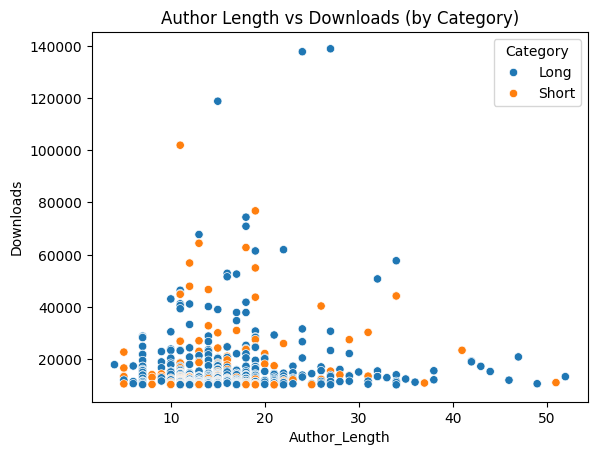

In [36]:
#Author Length vs Downloads (with Category)

plt.figure()
sns.scatterplot(x="Author_Length", y="Downloads", hue="Category", data=df)
plt.title("Author Length vs Downloads (by Category)")
plt.show()

# 🎯 Interpretation:

> No visible pattern

> Both short & long author names spread across all download ranges

# 🧠 Meaning:

👉 Author name length has no impact on downloads


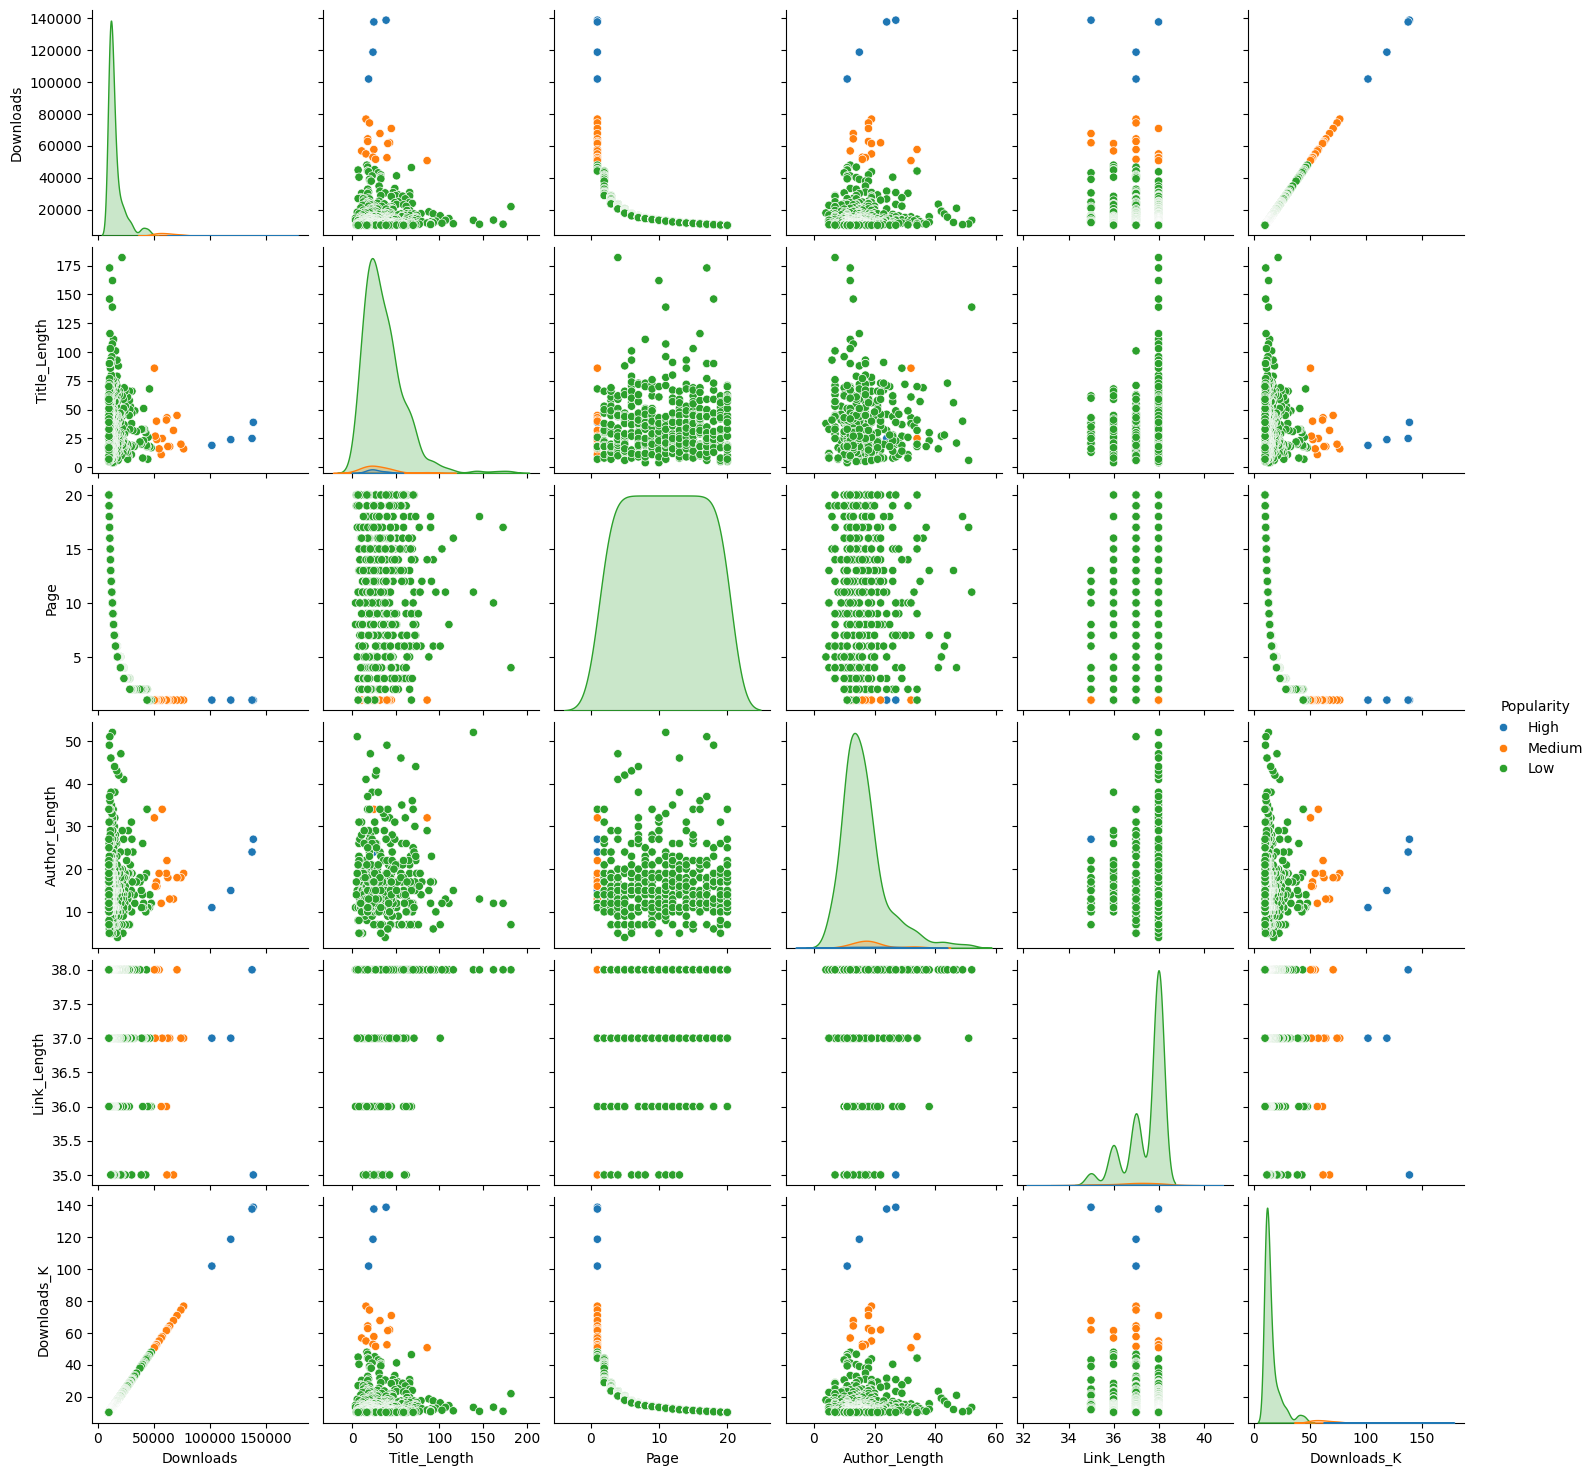

In [37]:
#Pairplot
sns.pairplot(df, hue="Popularity")
plt.show()

# 🎯 Interpretation:

> No strong linear relationships between variables

> Popularity groups are somewhat separated in downloads

# 🧠 Meaning:

👉 Dataset has:

> weak correlations

> but clear grouping via Popularity

# FINAL MULTIVARIATE INSIGHT

👉

> No single feature strongly predicts downloads

> Popularity is influenced by multiple hidden factors

> Feature engineering (Popularity) works well

# INSIGHTS & CONCLUSION

# 🧠 FINAL INSIGHTS 

🔹 Insight 1:

> Most books have moderate downloads (10k–20k range)

🔹 Insight 2:

> Few books have very high downloads (outliers)

→ indicates unequal popularity distribution

🔹 Insight 3:

> Title length has no strong impact on downloads

🔹 Insight 4:

> Author name length does not influence popularity
🔹 Insight 5:

> Engineered feature “Popularity” correctly groups data

🔹 Insight 6:

> Dataset shows weak correlations overall

# FINAL CONCLUSION

The analysis shows that book popularity varies significantly across the dataset, with most books having moderate downloads and a few highly popular outliers. No single feature such as title length or author length strongly influences downloads. The popularity classification effectively segments the data, indicating that book success depends on multiple external factors not captured in the dataset.


# RECOMMENDATIONS

👉

> Include genre/category data for better analysis

> Add publication year for trend analysis

> Use user ratings/reviews for deeper insights

> Apply machine learning models for prediction

# 🚀 📊 COMPLETE PROJECT FLOWCHART

<div align="center">

# 📊 Project Flowchart — Book Data Analysis

🔷 START

⬇️

📌 Problem Definition

Analyze book popularity using scraped data

⬇️

🌐 Data Source Selection
Project Gutenberg website

⬇️

🔍 Web Scraping
Used requests + BeautifulSoup
Collected 500 books data

⬇️

📊 Raw Data Extraction
Title
Author
Downloads
Link

⬇️

🧹 Data Cleaning
Removed unwanted text
Converted downloads to numeric
Structured dataset

⬇️

⚙️ Feature Engineering

Created new columns:

Title_Length
Category (Short / Long)
Book_ID
Page
Author_Length
Popularity
Link_Length
Downloads_K

⬇️

💾 Data Storage
Exported dataset to CSV

⬇️

═════════════════════════════
📈 Data Understanding
Shape → (500, 12)

Data Types

Missing Values → None

Statistical Summary
═════════════════════════════

⬇️

🔎 Exploratory Data Analysis (EDA)
📊 Univariate Analysis
Downloads Distribution
Popularity Count
Title Length

⬇️

📊 Bivariate Analysis
Title_Length vs Downloads
Category vs Popularity
Author_Length vs Downloads

⬇️

📊 Multivariate Analysis
Correlation Heatmap
Boxplot (Popularity vs Downloads)
Scatterplots (with hue)
Pairplot

⬇️

💡 Insights
Uneven popularity distribution
Weak correlations
No strong feature influence

⬇️

🎯 Conclusion
Book popularity varies widely
Depends on multiple external factors

⬇️

🚀 Recommendations
Add genre, ratings, publication year
Apply machine learning models

⬇️

✅ END PROJECT

</div>